# Step 2 – Brahami Maryam  
Optimisation Decision Tree et Random Forest + BaggingClassifier


In [19]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix


X_train = np.load(r'C:\Users\MERIEM\Documents\ESILV\Cours\A4_COURS_ING2\MachineLearning\Projet_ML\data\X_train_mfcc.npy')
y_train = np.load(r'C:\Users\MERIEM\Documents\ESILV\Cours\A4_COURS_ING2\MachineLearning\Projet_ML\data\y_train.npy')
X_dev   = np.load(r'C:\Users\MERIEM\Documents\ESILV\Cours\A4_COURS_ING2\MachineLearning\Projet_ML\data\X_dev_mfcc.npy')
y_dev   = np.load(r'C:\Users\MERIEM\Documents\ESILV\Cours\A4_COURS_ING2\MachineLearning\Projet_ML\data\y_dev.npy')

X_train.shape, X_dev.shape

((500, 26), (200, 26))

## Decision Tree Algorithme

In [15]:
# Decision Tree
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_dt,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

t0 = time.time()
grid_dt.fit(X_train, y_train)
dt_train_time = time.time() - t0

print("Best params DT :", grid_dt.best_params_)
print("Best CV AUC DT :", grid_dt.best_score_)
print("Training time :", dt_train_time, "seconds")

Best params DT : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5}
Best CV AUC DT : 0.80817188243951
Training time : 4.01181173324585 seconds


In [16]:
# Random Forest.
param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

t0 = time.time()
grid_rf.fit(X_train, y_train)
rf_train_time = time.time() - t0

print("Best params RF :", grid_rf.best_params_)
print("Best CV AUC RF :", grid_rf.best_score_)
print("Training time :", rf_train_time, "seconds")


Best params RF : {'max_depth': None, 'n_estimators': 300}
Best CV AUC RF : 0.9342538577241051
Training time : 1.9467270374298096 seconds


In [17]:
# BaggingClassifier basé sur le meilleur Decision Tree
bagging = BaggingClassifier(
    estimator=grid_dt.best_estimator_,
    n_estimators=20,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)

t0 = time.time()
bagging.fit(X_train, y_train)
bag_train_time = time.time() - t0

print("Bagging training time :", bag_train_time, "seconds")

Bagging training time : 0.19920849800109863 seconds


In [18]:
#Evaluation Function
def evaluate(name, model, X, y):
    t0 = time.time()
    y_proba = model.predict_proba(X)[:, 1]
    inference_time = time.time() - t0

    y_pred = (y_proba >= 0.5).astype(int)

    print(f"===== {name} =====")
    print("Accuracy :", accuracy_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))
    print("ROC-AUC  :", roc_auc_score(y, y_proba))
    print("Inference time :", inference_time, "seconds")
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))
    print()

# Evaluation of the three models
evaluate("Decision Tree (best)", grid_dt.best_estimator_, X_dev, y_dev)
evaluate("Random Forest (best)", grid_rf.best_estimator_, X_dev, y_dev)
evaluate("Bagging (Decision Tree)", bagging, X_dev, y_dev)


===== Decision Tree (best) =====
Accuracy : 0.79
F1-score : 0.8757396449704142
ROC-AUC  : 0.7367527173913043
Inference time : 0.0012116432189941406 seconds
Confusion matrix:
 [[ 10   6]
 [ 36 148]]

===== Random Forest (best) =====
Accuracy : 0.94
F1-score : 0.968421052631579
ROC-AUC  : 0.8916440217391304
Inference time : 0.02665114402770996 seconds
Confusion matrix:
 [[  4  12]
 [  0 184]]

===== Bagging (Decision Tree) =====
Accuracy : 0.94
F1-score : 0.967391304347826
ROC-AUC  : 0.8785665760869565
Inference time : 0.0043718814849853516 seconds
Confusion matrix:
 [[ 10   6]
 [  6 178]]



## Graphical representations of algorithms

<Figure size 1000x700 with 0 Axes>

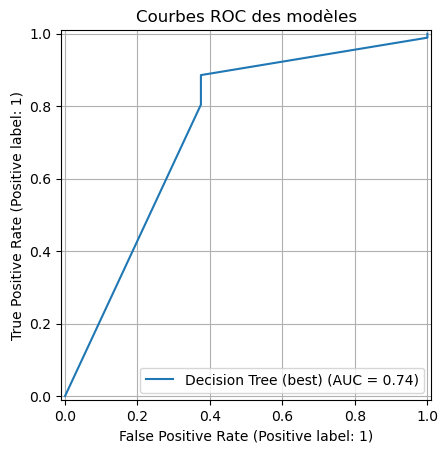

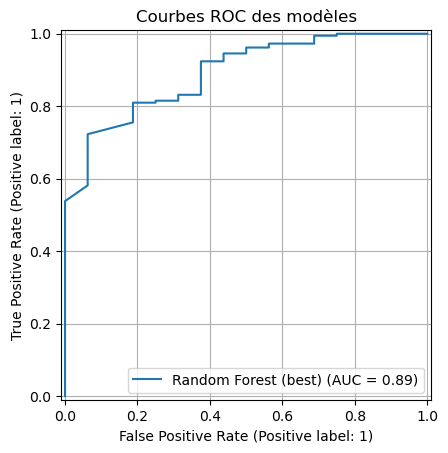

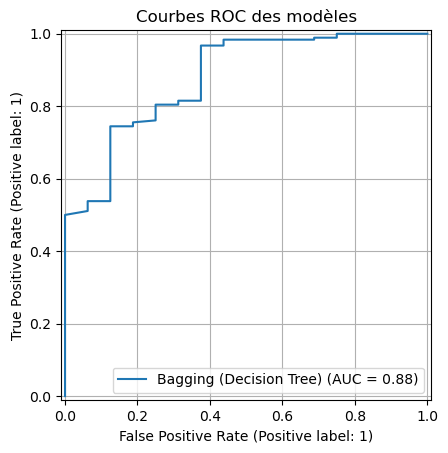

In [26]:
# --- ROC curves : Decision Tree, Random Forest, Bagging ---

plt.figure(figsize=(10, 7))

models = {
    "Decision Tree (best)": grid_dt.best_estimator_,
    "Random Forest (best)": grid_rf.best_estimator_,
    "Bagging (Decision Tree)": bagging,
}

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_dev, y_dev, name=name)
    plt.title("ROC curves of the models")
    plt.grid(True)
    plt.show()




## Confusion Matrix

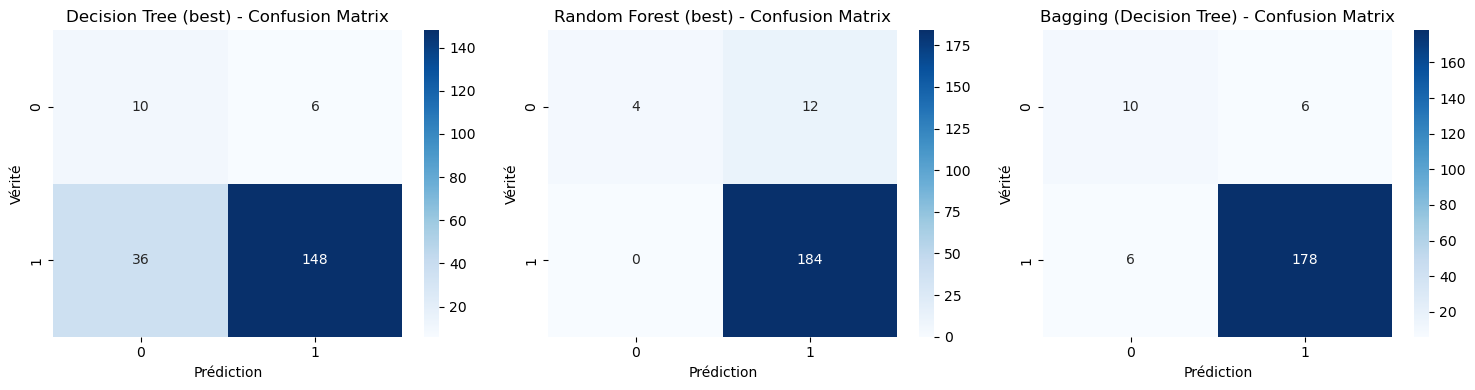

In [27]:
# --- Confusion Matrix in heatmap ---

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    y_pred = model.predict(X_dev)
    cm = confusion_matrix(y_dev, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Prédiction")
    plt.ylabel("Vérité")

plt.tight_layout()


## Barplots

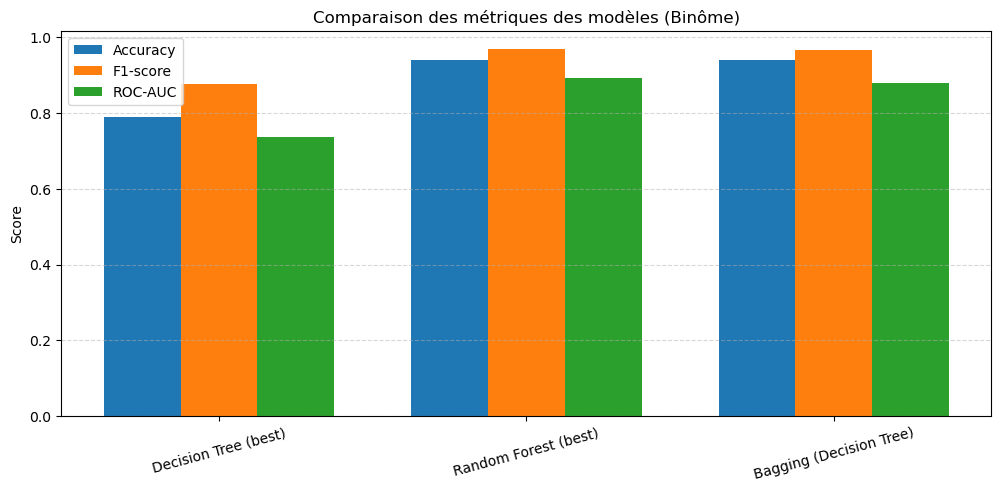

In [22]:
# --- Comparative barplots of metrics: Accuracy, F1, AUC ---

import numpy as np

accuracies = []
f1_scores = []
aucs = []

for name, model in models.items():
    y_proba = model.predict_proba(X_dev)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    accuracies.append(accuracy_score(y_dev, y_pred))
    f1_scores.append(f1_score(y_dev, y_pred))
    aucs.append(roc_auc_score(y_dev, y_proba))

labels = list(models.keys())
x = np.arange(len(labels))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.25, accuracies, width=0.25, label="Accuracy")
plt.bar(x,         f1_scores,   width=0.25, label="F1-score")
plt.bar(x + 0.25, aucs,         width=0.25, label="ROC-AUC")

plt.xticks(x, labels, rotation=15)
plt.ylabel("Score")
plt.title("Comparison of model metrics (Maryam)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


## Final comparison (ROC-AUC)

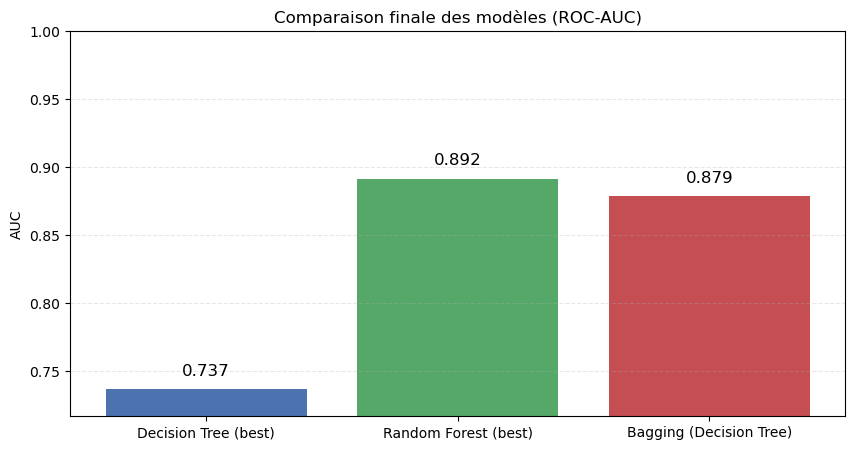

In [23]:
# --- Final comparison based on the ROC-AUC metric ---

plt.figure(figsize=(10, 5))

metric = aucs
plt.bar(labels, metric, color=["#4c72b0", "#55a868", "#c44e52"])

plt.title("Final comparison of the models (ROC-AUC)")
plt.ylabel("AUC")
plt.ylim(min(metric) - 0.02, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(metric):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=12)

plt.show()
